OCR

In [2]:
!pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 17.6 MB/s eta 0:00:00


In [6]:
!apt-get install -y tesseract-ocr

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [9]:
!pip install pytesseract

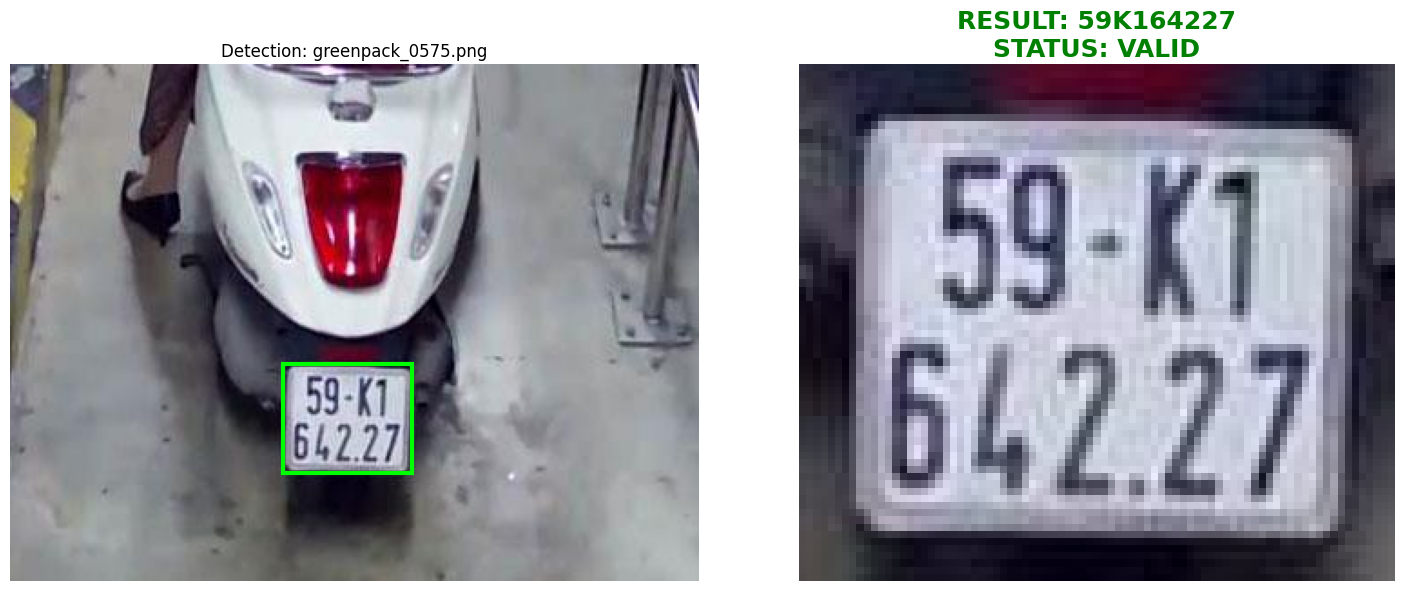

In [54]:
import os
import re
import cv2
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from ultralytics import YOLO
import easyocr

# ====================== 1. CẤU HÌNH ======================
WORKSPACE = Path('/content/drive/MyDrive/Project_YOLO')
IMG_TEST = WORKSPACE / 'images/val'
MODEL_PT = Path('/content/drive/MyDrive/yolo_runs/lp_yolov8n_30ep/weights/best.pt')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
model = YOLO(str(MODEL_PT))
reader = easyocr.Reader(['en'], gpu=(DEVICE == 'cuda'), verbose=False)

# ====================== 2. TIỀN XỬ LÝ & OCR ======================

def enhance_image_for_ocr(crop):
    """
    FIX MỚI:
    - Cắt sâu lề trái/phải để vứt khung đen gây lỗi thừa số 1.
    - Dùng Bilateral Filter thay vì Gaussian để không làm mất ngạnh số 7 và khe hở số 5.
    """
    h, w = crop.shape[:2]

    # Xén 4% lề trái/phải (chống viền đen dọc) và 2% lề trên/dưới
    crop = crop[max(1, int(h*0.02)):min(h-1, int(h*0.98)), max(1, int(w*0.04)):min(w-1, int(w*0.96))]

    # Scale 1.5 thay vì 2.0 để chữ vừa đủ lớn mà không bị béo dính nét
    scale = 1.5
    resized = cv2.resize(crop, None, fx=scale, fy=scale, interpolation=cv2.INTER_LANCZOS4)
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    # Cân bằng sáng CLAHE (giảm clipLimit xuống 1.5 để đỡ bị gắt hạt)
    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))
    contrast = clahe.apply(gray)

    # Sử dụng Bilateral Filter: Khử nhiễu nhưng GIỮ NGUYÊN CẠNH (Sắc nét)
    blur = cv2.bilateralFilter(contrast, d=5, sigmaColor=30, sigmaSpace=30)

    # Padding
    padded = cv2.copyMakeBorder(blur, 20, 20, 20, 20, cv2.BORDER_CONSTANT, value=255)
    return padded

def get_vietnamese_plate_logic(combined):
    combined = combined.upper()

    # Lọc bỏ mọi thứ không phải chữ/số
    combined = re.sub(r'[^A-Z0-9]', '', combined)
    if len(combined) < 6: return combined

    chars = list(combined)

    # Từ điển ép kiểu
    dict_num = {'O':'0', 'Q':'0', 'D':'0', 'I':'1', 'L':'1', 'T':'1', 'Z':'2', 'A':'4', 'E':'5', 'S':'5', 'G':'6', 'B':'8'}
    dict_char = {'0':'D', '1':'I', '2':'Z', '4':'A', '5':'S', '6':'G', '8':'B'}

    for i in range(len(chars)):
        if i in [0, 1]:
            chars[i] = dict_num.get(chars[i], chars[i])
        elif i == 2:
            chars[i] = dict_char.get(chars[i], chars[i])
        elif i >= 4:
            chars[i] = dict_num.get(chars[i], chars[i])

    # Xóa ký tự thừa nếu OCR nhặt rác bị vượt quá 9 ký tự (Biển VN tối đa 9 ký tự)
    # Thường ký tự rác (số 1 ảo) hay dính ở đầu hoặc cuối.
    final_str = "".join(chars)
    if len(final_str) > 9:
        if final_str[0] == '1': final_str = final_str[1:]
        elif final_str[-1] == '1': final_str = final_str[:-1]

    return final_str[:9]

def read_and_sort_ocr(crop_img, is_square_plate):
    processed_img = enhance_image_for_ocr(crop_img)
    img_h, img_w = processed_img.shape[:2]

    ocr_results = reader.readtext(
        processed_img,
        detail=1,
        decoder='beamsearch',
        allowlist='0123456789ABCDEFGHKLMNPRSTUVXYZ-.',
        mag_ratio=1.0,
        adjust_contrast=True,
        text_threshold=0.65,
        paragraph=False
    )

    valid_res = []

    for res in ocr_results:
        bbox, text, conf = res
        text = text.strip()

        # Hạ Conf xuống 0.25 để cứu dòng dưới bị mờ (Ảnh 2, Ảnh 7)
        if conf < 0.25:
            continue

        # TẦM SÁT: Nếu AI đọc ra đúng dấu gạch hoặc chấm -> Bỏ qua không lưu luôn (Triệt tiêu mầm mống - thành F)
        if text in ['-', '.', '--', '.-', '_']:
            continue

        x_coords = [p[0] for p in bbox]
        y_coords = [p[1] for p in bbox]
        box_w = max(x_coords) - min(x_coords)
        box_h = max(y_coords) - min(y_coords)

        # Hạ chiều cao filter xuống 16% khung hình (cứu dòng dưới của biển vuông)
        if box_h < img_h * 0.16:
            continue

        # Diệt số 1 do viền dọc (Tỷ lệ w/h siêu bé gọn)
        if box_w == 0 or (box_w / box_h) < 0.1:
            continue

        y_center = sum(y_coords) / 4.0
        valid_res.append({'text': text, 'bbox': bbox, 'y_center': y_center})

    if not valid_res: return ""

    if is_square_plate:
        avg_y = sum(item['y_center'] for item in valid_res) / len(valid_res)

        line_1 = [item for item in valid_res if item['y_center'] < avg_y]
        line_2 = [item for item in valid_res if item['y_center'] >= avg_y]

        line_1.sort(key=lambda x: min([p[0] for p in x['bbox']]))
        line_2.sort(key=lambda x: min([p[0] for p in x['bbox']]))

        text_1 = "".join([x['text'] for x in line_1])
        text_2 = "".join([x['text'] for x in line_2])
        return text_1 + text_2

    else:
        valid_res.sort(key=lambda x: min([p[0] for p in x['bbox']]))
        return "".join([x['text'] for x in valid_res])

# ====================== 3. PIPELINE XỬ LÝ CHÍNH ======================

def process_license_plate(img_path):
    img = cv2.imread(str(img_path))
    if img is None: return None, []

    results_yolo = model.predict(img_path, conf=0.5, device=DEVICE, verbose=False)
    final_results = []

    for box in results_yolo[0].boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)

        h_orig, w_orig = img.shape[:2]
        pad_x, pad_y = 6, 6
        crop = img[max(0, y1-pad_y):min(h_orig, y2+pad_y), max(0, x1-pad_x):min(w_orig, x2+pad_x)]

        h, w = crop.shape[:2]
        if h == 0 or w == 0: continue

        ratio = w / float(h)
        is_square_plate = ratio < 2.0

        plate_info = read_and_sort_ocr(crop, is_square_plate)

        final_plate_str = get_vietnamese_plate_logic(plate_info)

        # Regex kiểm tra form biển (Cả xe máy và ô tô)
        is_valid = bool(re.match(r'^\d{2}[A-Z][A-Z0-9]{0,2}\d{4,5}$', final_plate_str))

        final_results.append({
            'box': [x1, y1, x2, y2],
            'crop': crop,
            'plate': final_plate_str,
            'valid': is_valid
        })

    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB), final_results

# ====================== 4. CHẠY VÀ HIỂN THỊ ======================

test_files = [f for f in os.listdir(IMG_TEST) if f.endswith(('.png', '.jpg'))]
if test_files:
    sample = WORKSPACE / 'images/val' / random.choice(test_files)
    image_rgb, results = process_license_plate(sample)

    fig, ax = plt.subplots(1, 2, figsize=(15, 6))
    ax[0].imshow(image_rgb)
    ax[0].set_title(f"Detection: {sample.name}")
    ax[0].axis('off')

    if results:
        res = results[0]
        for r in results:
            b = r['box']
            ax[0].add_patch(patches.Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1],
                                               linewidth=3, edgecolor='#00FF00', fill=False))

        ax[1].imshow(cv2.cvtColor(res['crop'], cv2.COLOR_BGR2RGB))
        color = 'green' if res['valid'] else 'red'
        ax[1].set_title(f"RESULT: {res['plate']}\nSTATUS: {'VALID' if res['valid'] else 'INVALID'}",
                        color=color, fontsize=18, fontweight='bold')
        ax[1].axis('off')

    plt.tight_layout()
    plt.show()